In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape: (60000, 28, 28)
Testing Shape : (10000, 28, 28)


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Flattened Shape:", x_train.shape)

Flattened Shape: (60000, 784)


In [ ]:
latent_dim = 8

pca = PCA(n_components=latent_dim)

pca.fit(x_train)

x_test_pca = pca.transform(x_test)

x_test_reconstructed_pca = pca.inverse_transform(x_test_pca)

mse_pca = mean_squared_error(x_test,x_test_reconstructed_pca)

print("PCA MSE:", mse_pca)

PCA MSE: 0.03744099859719873


AE


In [ ]:
input_dim = 784
latent_dim = 64

input_layer = Input(shape=(input_dim,))

# Encoder
h1 = Dense(128, activation='relu')(input_layer)
h2 = Dense(64, activation='relu')(h1)
latent = Dense(latent_dim, activation='relu')(h2)

# Decoder
d1 = Dense(64, activation='relu')(latent)
d2 = Dense(128, activation='relu')(d1)

output_layer = Dense( input_dim, activation='sigmoid')(d2)

autoencoder = Model(  inputs=input_layer, outputs=output_layer)

autoencoder.compile(  optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,512 (884.81 KB)

 Trainable params: 226,512 (884.81 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0643 - val_loss: 0.0354
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0297 - val_loss: 0.0244
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0225 - val_loss: 0.0200
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0193 - val_loss: 0.0180
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0175 - val_loss: 0.0163
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0162 - val_loss: 0.0152
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0151 - val_loss: 0.0143
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0141 - val_loss: 0.0133
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0132 - val_loss: 0.0125
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0124 - val_loss: 0.0118
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0118 - val_loss: 0.0113
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
x_test_reconstructed_ae = autoencoder.predict(x_test)

mse_ae = mean_squared_error(x_test,x_test_reconstructed_ae
)

print("Autoencoder MSE:", mse_ae)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Autoencoder MSE: 0.00873628745302936


In [ ]:
print("\n----- Comparison -----")
print("PCA MSE         :", mse_pca)
print("Autoencoder MSE :", mse_ae)


----- Comparison -----
PCA MSE         : 0.03744099859719873
Autoencoder MSE : 0.00873628745302936


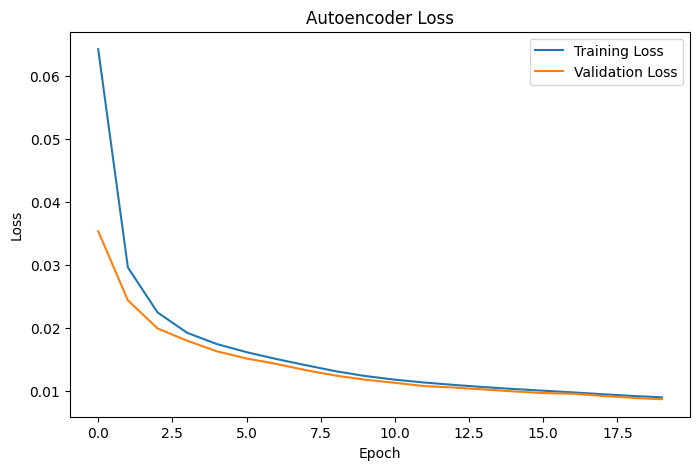

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Loss")

plt.legend()
plt.show()

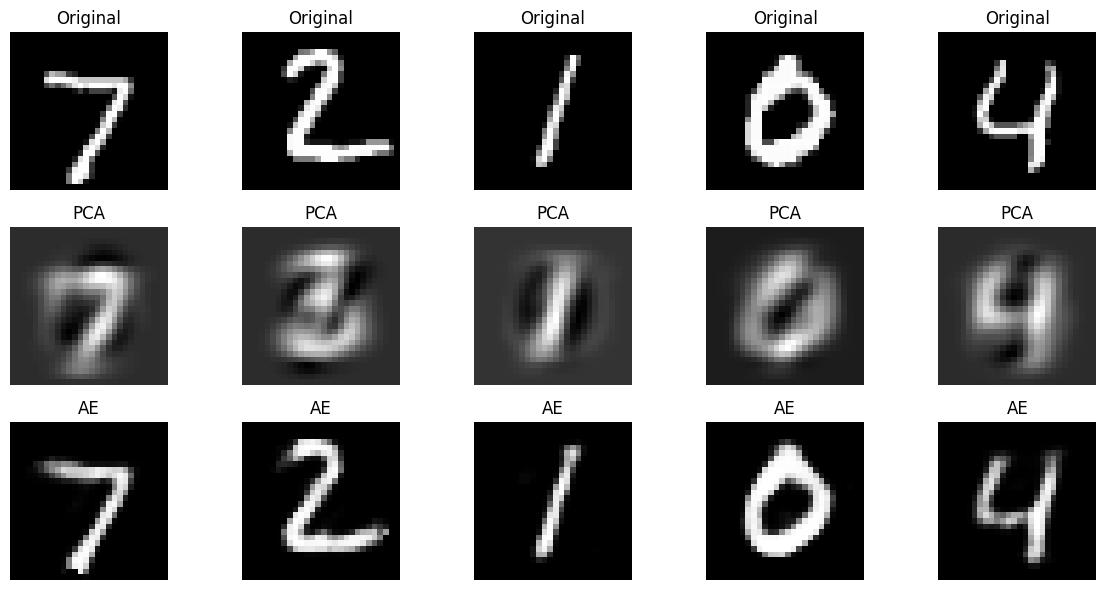

In [ ]:
n = 5

plt.figure(figsize=(12,6))

for i in range(n):

    # Original
    plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # PCA
    plt.subplot(3, n, i+n+1)
    plt.imshow(x_test_reconstructed_pca[i].reshape(28,28),cmap='gray')
    plt.title("PCA")
    plt.axis("off")

    # Autoencoder
    plt.subplot(3, n, i+2*n+1)
    plt.imshow(x_test_reconstructed_ae[i].reshape(28,28), cmap='gray')
    plt.title("AE")
    plt.axis("off")

plt.tight_layout()
plt.show()